In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import pickle

In [2]:
df = pd.read_csv("customer_shopping_data.csv")

In [3]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [4]:
df.shape

(99457, 10)

In [5]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [7]:
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [10]:
df["gender"].value_counts()

gender
Female    59482
Male      39975
Name: count, dtype: int64

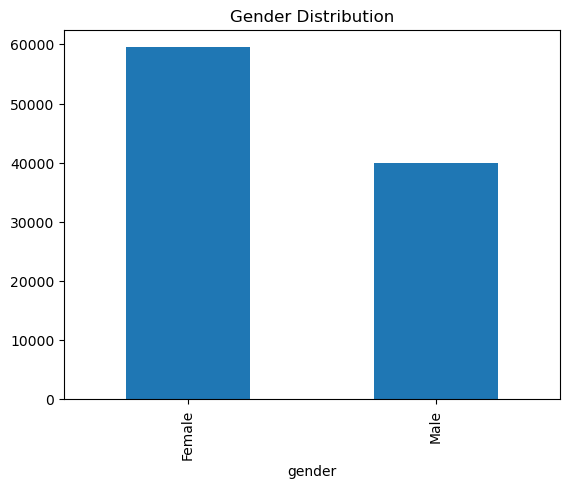

In [11]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

In [12]:
df["shopping_mall"].value_counts()

shopping_mall
Mall of Istanbul     19943
Kanyon               19823
Metrocity            15011
Metropol AVM         10161
Istinye Park          9781
Zorlu Center          5075
Cevahir AVM           4991
Forum Istanbul        4947
Viaport Outlet        4914
Emaar Square Mall     4811
Name: count, dtype: int64

In [13]:
df["payment_method"].value_counts()

payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: count, dtype: int64

In [14]:
df["category"].value_counts()

category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64

In [15]:
df["total_price"] = df["quantity"] * df["price"]

In [16]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], dayfirst=True)

In [17]:
df["month"] = df["invoice_date"].dt.month

In [18]:
df["year"] = df["invoice_date"].dt.year

In [19]:
le_gender = LabelEncoder()
le_category = LabelEncoder()
le_payment = LabelEncoder()
le_mall = LabelEncoder()

In [20]:
df["gender"] = le_gender.fit_transform(df["gender"])

In [21]:
df["category"] = le_category.fit_transform(df["category"])

In [22]:
df["payment_method"] = le_payment.fit_transform(df["payment_method"])

In [23]:
df["shopping_mall"] = le_mall.fit_transform(df["shopping_mall"])

In [24]:
features = [
    "gender",
    "age",
    "category",
    "quantity",
    "price",
    "payment_method",
    "shopping_mall",
    "total_price",
    "month"
]

In [25]:
X = df[features]

In [26]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [27]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

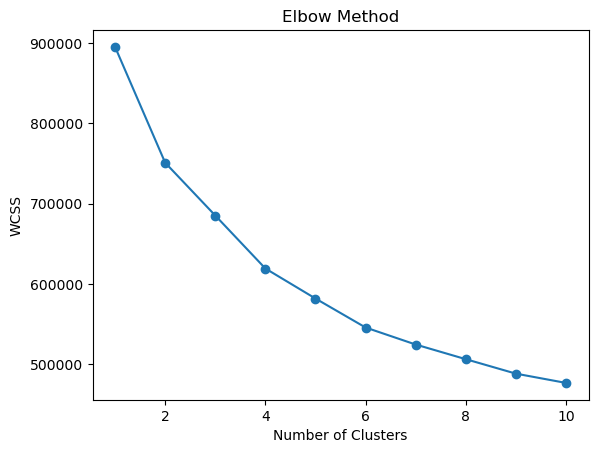

In [28]:
plt.plot(range(1, 11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [29]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [30]:
df["cluster"] = clusters

In [31]:
score = silhouette_score(X_scaled, clusters)

print(score)

0.13064508810762077


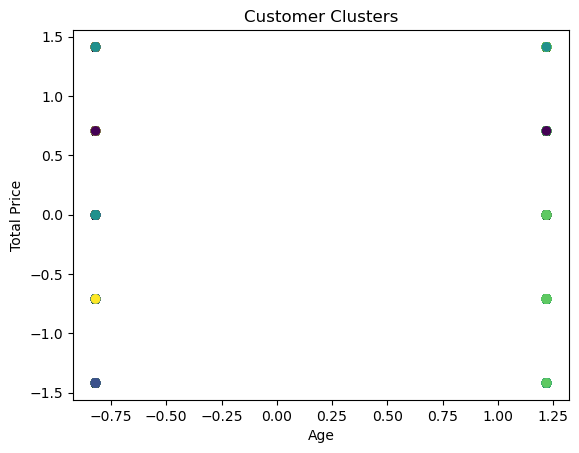

In [32]:
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 3],
    c=clusters
)

plt.xlabel("Age")

plt.ylabel("Total Price")

plt.title("Customer Clusters")

plt.show()

In [33]:
df.groupby("cluster")[features].mean()

,gender,age,category,quantity,price,payment_method,shopping_mall,total_price,month
cluster,,,,,,,,,
0,0.405762,43.469344,4.854669,4.284559,3339.864605,0.745671,4.715725,14511.546280,6.146324
1,0.000000,43.580977,1.807714,2.584707,463.948149,0.290240,4.724819,1452.358616,6.101115
2,0.408176,43.337514,6.328168,2.804534,247.555634,0.717653,4.707826,556.905253,6.096949
3,1.000000,43.461998,1.783101,2.824160,514.327040,0.676661,4.725583,1704.908147,6.131146
4,0.090752,43.209584,1.765431,3.590857,689.234788,1.595423,4.706068,2642.171058,6.109647


In [34]:
import os
os.makedirs("models", exist_ok=True)

In [35]:
pickle.dump(
    kmeans,
    open("models/kmeans.pkl", "wb")
)

In [36]:
pickle.dump(
    scaler,
    open("models/scaler.pkl", "wb")
)

In [37]:
pickle.dump(
    features,
    open("models/features.pkl", "wb")
)

In [38]:
pickle.dump(
    le_gender,
    open("models/le_gender.pkl", "wb")
)

pickle.dump(
    le_category,
    open("models/le_category.pkl", "wb")
)

pickle.dump(
    le_payment,
    open("models/le_payment.pkl", "wb")
)

pickle.dump(
    le_mall,
    open("models/le_mall.pkl", "wb")
)